# PVPRO-lite local debug notebook

Use this notebook to diagnose why the web app's PVPRO step returned a flat / weird
result on your dataset. It runs the exact same PVPRO-lite logic, but with verbose
printing at every step so you can see:

- the data shape after the irradiance + NaN + V/I filters,
- the global starting-point `p0` derived from the top-decile irradiance,
- every per-window fit's input shape, loss, and recovered parameters,
- whether parameters are pinning to their bounds,
- the per-window p_mp_ref time series and how it's trending.

**Requirements:** numpy, pandas, scipy, scikit-learn, matplotlib, plotly.
Everything else is reimplemented inline — no pvpro / pvlib / rdtools / solar-data-tools needed.

**How to use:**
1. In the "Configuration" cell below, set `DATA_PATH` to your CSV/Parquet file.
2. Set the four column names (`V_KEY`, `I_KEY`, `G_KEY`, `T_KEY`) to whatever
   the web app identified in Step 1.
3. Set the PV-system metadata (`CELLS_IN_SERIES`, `MODULES_PER_STRING`, etc.) to
   the same values you used in the web app.
4. Run all cells top-to-bottom.


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize as scipy_minimize
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

# Physical constants
Q_E = 1.602176634e-19
K_B = 1.380649e-23
T_REF_K = 25.0 + 273.15
G_REF = 1000.0

TECH_TABLE = {
    "mono-c-Si":  (1.121, -0.0002677),
    "multi-c-Si": (1.121, -0.0002677),
    "GaAs":       (1.424, -0.000433),
    "CIGS":       (1.15,  -0.00001),
    "CdTe":       (1.475, -0.0003),
}


## 2. Configuration — edit these for your dataset

In [2]:
# -- File path -------------------------------------------------------------
DATA_PATH = "/Users/baojie/Library/CloudStorage/OneDrive-Personal/LBL_study/pv_copilot/sys_1278_downsampled_with_VI.parquet"   # <-- CHANGE THIS

# -- Column mapping (must match what the web app identified in Step 1) ------
V_KEY = "inv1_input_voltage"   # DC Voltage column   <-- CHANGE
I_KEY = "inv1_input_current"   # DC Current column   <-- CHANGE
G_KEY = "poa_irradiance"       # Irradiance column   <-- CHANGE
T_KEY = "module_temperature_C" # Module-T column     <-- CHANGE

# -- PV system metadata -----------------------------------------------------
CELLS_IN_SERIES    = 60        # cells in series PER MODULE
MODULES_PER_STRING = 1         # modules in series in one string
PARALLEL_STRINGS   = 1         # parallel strings the measured V/I cover
ALPHA_ISC          = 0.0046    # short-circuit-current temp coeff (A/degC)
TECHNOLOGY         = "mono-c-Si"   # see TECH_TABLE above
DELTA_T            = 3.0       # T_cell - T_module (deg C)
RESISTANCE_SHUNT_REF = 600.0   # initial guess for shunt resistance

# -- PVPRO-lite tuning ------------------------------------------------------
DAYS_PER_RUN          = 14
ITERATIONS_PER_YEAR   = 12
IRRADIANCE_THRESHOLD  = 200.0  # drop points with G <= this (W/m^2)
MIN_POINTS_PER_WINDOW = 20

# -- How many windows to print verbosely? -----------------------------------
PRINT_FIRST_N_WINDOWS = 3      # detailed printout for the first N windows


## 3. Load the data

Supports CSV, Parquet, and Excel. The script auto-detects the time index — if
the data has a datetime column, set it as the index in this cell before continuing.

In [3]:
path = DATA_PATH
if path.endswith(".csv"):
    df_raw = pd.read_csv(path)
elif path.endswith(".parquet"):
    df_raw = pd.read_parquet(path)
elif path.endswith((".xls", ".xlsx")):
    df_raw = pd.read_excel(path)
else:
    raise ValueError(f"Unrecognised file extension: {path}")

# Try to find a datetime index. Adjust this block if your time column has a
# different name.
if not isinstance(df_raw.index, pd.DatetimeIndex):
    for candidate in ("time", "timestamp", "datetime", "date", "Time", "Timestamp"):
        if candidate in df_raw.columns:
            df_raw[candidate] = pd.to_datetime(df_raw[candidate])
            df_raw = df_raw.set_index(candidate)
            print(f"Set index from column '{candidate}'.")
            break
    else:
        # Try the first column.
        try:
            first = df_raw.columns[0]
            df_raw[first] = pd.to_datetime(df_raw[first])
            df_raw = df_raw.set_index(first)
            print(f"Set index from first column '{first}'.")
        except Exception:
            raise ValueError(
                "Could not find a datetime column. Set df_raw.index manually."
            )

print(f"Loaded {len(df_raw):,} rows from {path}")
print(f"Time span: {df_raw.index.min()} -> {df_raw.index.max()} "
      f"({(df_raw.index.max() - df_raw.index.min()).days} days)")
print(f"\nColumns: {list(df_raw.columns)}")
df_raw.head()


Loaded 78,066 rows from /Users/baojie/Library/CloudStorage/OneDrive-Personal/LBL_study/pv_copilot/sys_1278_downsampled_with_VI.parquet
Time span: 2011-08-30 23:00:00 -> 2020-07-26 16:00:00 (3252 days)

Columns: ['poa_irradiance', 'module_temperature_C', 'ac_power', 'dc_power', 'inv1_input_voltage', 'inv1_input_current']


,poa_irradiance,module_temperature_C,ac_power,dc_power,inv1_input_voltage,inv1_input_current
2011-08-30 23:00:00,0.293000,26.451389,NaN,NaN,NaN,NaN
2011-08-31 00:00:00,0.342000,26.681944,NaN,NaN,NaN,NaN
2011-08-31 01:00:00,0.268500,24.905556,NaN,NaN,NaN,NaN
2011-08-31 02:00:00,0.244250,22.925000,NaN,NaN,NaN,NaN
2011-08-31 03:00:00,0.325667,19.938889,NaN,NaN,NaN,NaN


## 4. Check that your column-name configuration is valid

In [4]:
for name, key in [("V_KEY", V_KEY), ("I_KEY", I_KEY),
                  ("G_KEY", G_KEY), ("T_KEY", T_KEY)]:
    if key not in df_raw.columns:
        raise KeyError(
            f"{name} = '{key}' not found in dataframe. "
            f"Available columns: {list(df_raw.columns)}"
        )
print("All four column keys are present in the dataframe.")
print()
print(df_raw[[V_KEY, I_KEY, G_KEY, T_KEY]].describe())


All four column keys are present in the dataframe.

       inv1_input_voltage  inv1_input_current  poa_irradiance  \
count        75845.000000        75822.000000    77669.000000   
mean           196.716928           61.671481      278.702589   
std            168.174550           88.879338      384.743391   
min              2.000000           -2.000000        0.000000   
25%              9.750000           -1.500000        0.162667   
50%            315.250000            0.500000        9.497250   
75%            353.250000          121.750000      551.830750   
max            464.750000          310.250000     1341.186500   

       module_temperature_C  
count          77625.000000  
mean              22.256643  
std               14.856460  
min              -15.848611  
25%               10.093056  
50%               20.926389  
75%               32.666667  
max               65.488889  


## 5. Plot the four raw signals

Look at these carefully. If V_KEY is showing values around 0–1 V or 200–400 V
when you expected ~30 V, you've probably mapped a string voltage to a per-module
slot and need to adjust `MODULES_PER_STRING`. Similarly for current and parallel
strings.

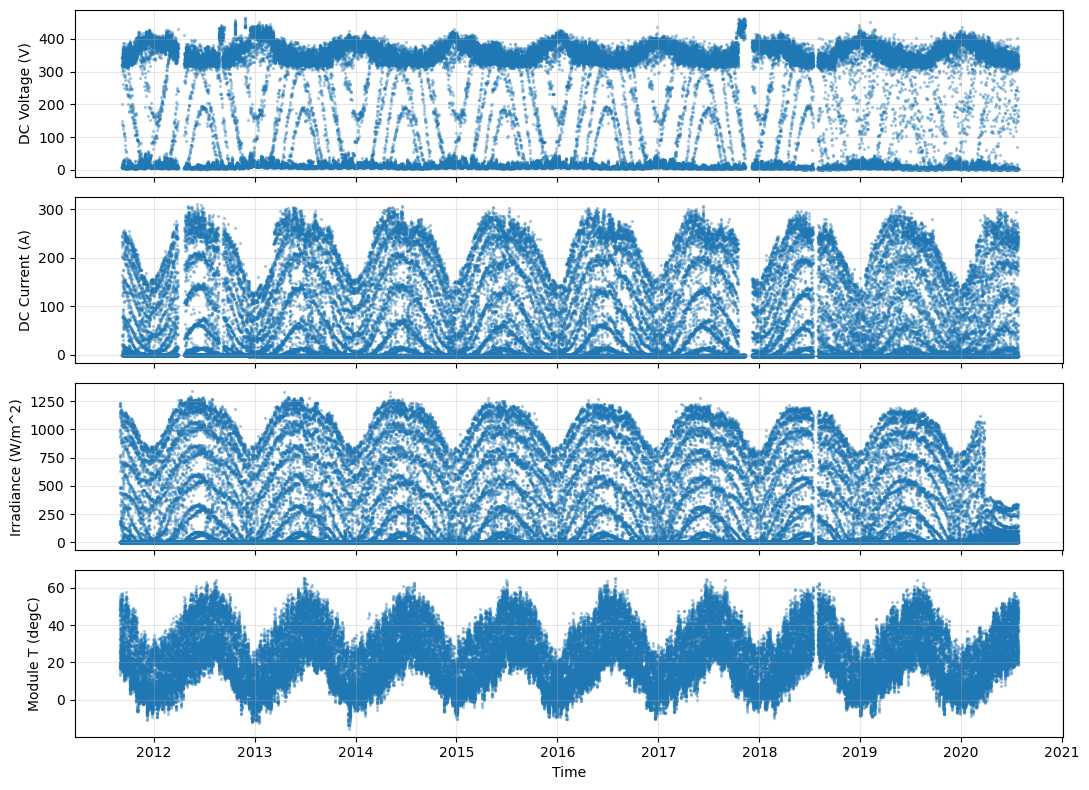

V range:  2.00 - 464.75
I range:  -2.00 - 310.25
G range:  0.00 - 1341.19
T range:  -15.85 - 65.49

Expected: V ~10-50 per module (or N*30 for an N-module string)
          I ~1-12 per string  (or N*5 for N parallel strings)
          G 0-1200 W/m^2, T 0-70 degC


In [5]:
fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
for ax, key, label in zip(axes, [V_KEY, I_KEY, G_KEY, T_KEY],
                          ["DC Voltage (V)", "DC Current (A)",
                           "Irradiance (W/m^2)", "Module T (degC)"]):
    ax.scatter(df_raw.index, df_raw[key], s=2, alpha=0.3)
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

print(f"V range:  {df_raw[V_KEY].min():.2f} - {df_raw[V_KEY].max():.2f}")
print(f"I range:  {df_raw[I_KEY].min():.2f} - {df_raw[I_KEY].max():.2f}")
print(f"G range:  {df_raw[G_KEY].min():.2f} - {df_raw[G_KEY].max():.2f}")
print(f"T range:  {df_raw[T_KEY].min():.2f} - {df_raw[T_KEY].max():.2f}")
print(f"\nExpected: V ~10-50 per module (or N*30 for an N-module string)")
print(f"          I ~1-12 per string  (or N*5 for N parallel strings)")
print(f"          G 0-1200 W/m^2, T 0-70 degC")


## 6. PVPRO-lite core functions (standalone copy)

These are identical to what the web app uses, except every function logs its
shape and key statistics. Read through them only if you suspect a math bug.

In [6]:
def calcparams_desoto_lite(G, T_cell_C, IL_ref, I0_ref, Rs_ref, Rsh_ref,
                            n_diode, cells_in_series, alpha_isc, Eg_ref, dEgdT):
    """De Soto translation from STC reference parameters to operating G, T."""
    G  = np.asarray(G, dtype=float)
    Tc = np.asarray(T_cell_C, dtype=float) + 273.15
    dT = Tc - T_REF_K
    Eg = Eg_ref * (1.0 + dEgdT * dT)

    IL = (G / G_REF) * (IL_ref + alpha_isc * dT)

    Vth_ratio = (Q_E / K_B) * (Eg_ref / T_REF_K - Eg / Tc)
    I0 = I0_ref * (Tc / T_REF_K) ** 3 * np.exp(Vth_ratio)

    Rs = np.full_like(G, Rs_ref, dtype=float)

    # Shunt resistance scales inversely with G, with a tiny extra conductance
    # so it stays bounded at G ~ 0.
    Gsh_extra = 1e-5
    Rsh_inv = (G / G_REF) / Rsh_ref + Gsh_extra
    Rsh = 1.0 / Rsh_inv

    nNsVth = n_diode * cells_in_series * (K_B * Tc / Q_E)
    return IL, I0, Rs, Rsh, nNsVth


def mpp_vectorised(IL, I0, Rs, Rsh, nNsVth, n_iter=20):
    """Vectorised MPP solver: Newton iteration on dP/dVd = 0."""
    IL  = np.asarray(IL, dtype=float)
    I0  = np.asarray(I0, dtype=float)
    Rs  = np.asarray(Rs, dtype=float)
    Rsh = np.asarray(Rsh, dtype=float)
    nNsVth = np.asarray(nNsVth, dtype=float)

    with np.errstate(divide="ignore", invalid="ignore"):
        Voc_est = nNsVth * np.log(np.maximum(IL / np.maximum(I0, 1e-30), 1.0) + 1.0)
    valid = (IL > 0) & np.isfinite(Voc_est) & (Voc_est > 0)
    Vd = np.where(valid, 0.7 * Voc_est, 0.0)

    for _ in range(n_iter):
        arg = np.clip(Vd / np.maximum(nNsVth, 1e-30), -100.0, 100.0)
        exp_a = np.exp(arg)
        I_diode = I0 * (exp_a - 1.0)
        I_term  = IL - I_diode - Vd / Rsh
        g = I0 / np.maximum(nNsVth, 1e-30) * exp_a
        dI = -g - 1.0 / Rsh
        V_term = Vd - I_term * Rs
        dV = 1.0 - Rs * dI
        f = dV * I_term + V_term * dI
        d2I = -g / np.maximum(nNsVth, 1e-30)
        d2V =  Rs * g / np.maximum(nNsVth, 1e-30)
        f_prime = d2V * I_term + 2.0 * dV * dI + V_term * d2I
        step = np.where(np.abs(f_prime) > 1e-30, f / f_prime, 0.0)
        Vd_new = Vd - step
        Vd = np.where(valid, np.clip(Vd_new, 1e-6, 1.05 * Voc_est), Vd)

    arg = np.clip(Vd / np.maximum(nNsVth, 1e-30), -100.0, 100.0)
    I_diode = I0 * (np.exp(arg) - 1.0)
    I_term  = IL - I_diode - Vd / Rsh
    V_term  = Vd - I_term * Rs
    V_term = np.where(valid, V_term, 0.0)
    I_term = np.where(valid, I_term, 0.0)
    return V_term, I_term


FIT_PARAMS = ("photocurrent_ref", "saturation_current_ref",
              "resistance_series_ref", "resistance_shunt_ref", "diode_factor")


def p_to_x(p, key):
    """Physical -> numerical fit variable (log-transform for stability)."""
    if key == "saturation_current_ref": return np.log(p) + 23.0
    if key == "resistance_shunt_ref":   return np.log(p) / 2.0 + 1.0
    if key == "resistance_series_ref":  return p * 2.2
    return p


def x_to_p(x, key):
    if key == "saturation_current_ref": return float(np.exp(x - 23.0))
    if key == "resistance_shunt_ref":   return float(np.exp(2.0 * (x - 1.0)))
    if key == "resistance_series_ref":  return float(x / 2.2)
    return float(x)


def predict_vi(params, G, T_cell, cells_in_series, alpha_isc, Eg_ref, dEgdT):
    IL, I0, Rs, Rsh, nNsVth = calcparams_desoto_lite(
        G, T_cell,
        IL_ref=params["photocurrent_ref"],
        I0_ref=params["saturation_current_ref"],
        Rs_ref=params["resistance_series_ref"],
        Rsh_ref=params["resistance_shunt_ref"],
        n_diode=params["diode_factor"],
        cells_in_series=cells_in_series, alpha_isc=alpha_isc,
        Eg_ref=Eg_ref, dEgdT=dEgdT,
    )
    return mpp_vectorised(IL, I0, Rs, Rsh, nNsVth)


def loss_fn(x, fit_params, G, T, V_meas, I_meas, V_scale, I_scale,
            cells_in_series, alpha_isc, Eg_ref, dEgdT):
    params = {k: x_to_p(x[i], k) for i, k in enumerate(fit_params)}
    V_pred, I_pred = predict_vi(params, G, T, cells_in_series, alpha_isc,
                                Eg_ref, dEgdT)
    v_err = (V_pred - V_meas) / V_scale
    i_err = (I_pred - I_meas) / I_scale
    return float(np.nanmean(v_err ** 2 + i_err ** 2))


def fit_window(G, T, V_meas, I_meas, p0, lower_bounds, upper_bounds,
               cells_in_series, alpha_isc, Eg_ref, dEgdT,
               saturation_current_multistart=(0.2, 0.5, 1.0, 2.0, 5.0),
               verbose=False):
    """Fit the 5 SDM parameters in one window. Returns dict or None."""
    fit_params = list(FIT_PARAMS)
    x_lo = np.array([p_to_x(lower_bounds[k], k) for k in fit_params])
    x_hi = np.array([p_to_x(upper_bounds[k], k) for k in fit_params])
    bounds = list(zip(x_lo, x_hi))

    Io_seed = p0["saturation_current_ref"]
    V_scale = max(float(np.nanmedian(V_meas)), 1e-3)
    I_scale = max(float(np.nanmedian(I_meas)), 1e-3)

    best, best_loss = None, np.inf
    for mult in saturation_current_multistart:
        p0_try = dict(p0)
        p0_try["saturation_current_ref"] = Io_seed * mult
        x0 = np.array([p_to_x(p0_try[k], k) for k in fit_params])
        x0 = np.minimum(np.maximum(x0, x_lo), x_hi)
        try:
            res = scipy_minimize(
                loss_fn, x0=x0, bounds=bounds, method="L-BFGS-B",
                args=(fit_params, G, T, V_meas, I_meas, V_scale, I_scale,
                      cells_in_series, alpha_isc, Eg_ref, dEgdT),
                options={"maxiter": 80, "ftol": 1e-7, "disp": False},
            )
            if verbose:
                print(f"    Io x{mult:>4.1f}: loss = {res.fun:.4e}, "
                      f"nit = {res.nit}, status = {res.message}")
        except Exception as e:
            if verbose:
                print(f"    Io x{mult:>4.1f}: EXCEPTION {e}")
            continue
        if np.isfinite(res.fun) and res.fun < best_loss:
            best, best_loss = res, res.fun

    if best is None:
        return None
    return {k: x_to_p(best.x[i], k) for i, k in enumerate(fit_params)} | {
        "loss": float(best.fun),
        "x_at_optimum": best.x.copy(),
        "x_lo": x_lo, "x_hi": x_hi,
    }


def estimate_p0_simple(G, T, V, I, cells_in_series, alpha_isc, Eg_ref, dEgdT):
    if len(G) < 10:
        return None
    g_hi = np.nanquantile(G, 0.9)
    mask = G >= g_hi
    if mask.sum() < 5:
        mask = np.ones_like(G, dtype=bool)
    Vmp_med = float(np.nanmedian(V[mask]))
    Imp_med = float(np.nanmedian(I[mask]))
    Gmed    = float(np.nanmedian(G[mask]))
    if Vmp_med <= 0 or Imp_med <= 0 or Gmed <= 0:
        return None
    IL_ref_guess = Imp_med * (G_REF / Gmed)
    n_guess = 1.03
    nNsVth_ref = n_guess * cells_in_series * (K_B * T_REF_K / Q_E)
    I0_ref_guess = max(IL_ref_guess * np.exp(-Vmp_med / nNsVth_ref), 1e-13)
    return dict(
        photocurrent_ref       = float(np.clip(IL_ref_guess, 0.1, 20.0)),
        saturation_current_ref = float(np.clip(I0_ref_guess, 1e-13, 1e-5)),
        resistance_series_ref  = 0.4,
        resistance_shunt_ref   = 600.0,
        diode_factor           = n_guess,
    )

print("Core functions defined.")


Core functions defined.


## 7. Filter the data exactly like the web app does

Drops NaNs, points with G <= IRRADIANCE_THRESHOLD, and points where V*I <= 0
(non-operating).

In [7]:
df_p = df_raw[[V_KEY, I_KEY, G_KEY, T_KEY]].copy()
df_p.index = pd.to_datetime(df_p.index)

print(f"Start:                       {len(df_p):>8,} rows")
df_p = df_p.dropna()
print(f"After dropna:                {len(df_p):>8,} rows")
df_p = df_p[df_p[G_KEY] > IRRADIANCE_THRESHOLD]
print(f"After G > {IRRADIANCE_THRESHOLD:.0f}:             {len(df_p):>8,} rows")
df_p = df_p[(df_p[V_KEY] > 0) & (df_p[I_KEY] > 0)]
print(f"After V>0 and I>0:           {len(df_p):>8,} rows")

if len(df_p) < 100:
    raise ValueError(
        f"Only {len(df_p)} rows remain — too few for PVPRO. "
        "Loosen the irradiance threshold or the upstream Step-2 filters."
    )

# Per-module / per-string normalisation
V_arr  = df_p[V_KEY].to_numpy() / max(MODULES_PER_STRING, 1)
I_arr  = df_p[I_KEY].to_numpy() / max(PARALLEL_STRINGS, 1)
G_arr  = df_p[G_KEY].to_numpy()
Tc_arr = df_p[T_KEY].to_numpy() + DELTA_T

print(f"\nAfter normalisation (V/MPS, I/PS, Tcell=Tmod+{DELTA_T}):")
print(f"  V per module: median {np.median(V_arr):.2f}, range [{V_arr.min():.2f}, {V_arr.max():.2f}]")
print(f"  I per string: median {np.median(I_arr):.2f}, range [{I_arr.min():.2f}, {I_arr.max():.2f}]")
print(f"  G:            median {np.median(G_arr):.0f}, range [{G_arr.min():.0f}, {G_arr.max():.0f}]")
print(f"  Tcell:        median {np.median(Tc_arr):.1f}, range [{Tc_arr.min():.1f}, {Tc_arr.max():.1f}]")
print(f"  Implied Pmp per module ~ V*I = {np.median(V_arr) * np.median(I_arr):.1f} W")

if np.median(V_arr) > 80 or np.median(V_arr) * np.median(I_arr) > 500:
    print("\n*** WARNING: per-module V or P seems too large. ***")
    print("    Check MODULES_PER_STRING and PARALLEL_STRINGS.")
    print("    A typical c-Si module has Vmp ~ 30 V, Imp ~ 8 A, Pmp ~ 300 W.")


Start:                         78,066 rows
After dropna:                  75,822 rows
After G > 200:               28,730 rows
After V>0 and I>0:             28,352 rows

After normalisation (V/MPS, I/PS, Tcell=Tmod+3.0):
  V per module: median 350.25, range [310.50, 450.50]
  I per string: median 154.50, range [4.00, 310.25]
  G:            median 729, range [200, 1341]
  Tcell:        median 38.2, range [1.4, 68.5]
  Implied Pmp per module ~ V*I = 54113.6 W

*** WARNING: per-module V or P seems too large. ***
    Check MODULES_PER_STRING and PARALLEL_STRINGS.
    A typical c-Si module has Vmp ~ 30 V, Imp ~ 8 A, Pmp ~ 300 W.


## 8. Estimate global starting point `p0`

In [ ]:
Eg_ref, dEgdT = TECH_TABLE[TECHNOLOGY]

p0_global = estimate_p0_simple(G_arr, Tc_arr, V_arr, I_arr,
                               CELLS_IN_SERIES, ALPHA_ISC, Eg_ref, dEgdT)
if p0_global is None:
    raise RuntimeError("Could not derive a starting point.")
p0_global["resistance_shunt_ref"] = float(RESISTANCE_SHUNT_REF)

print("Global p0:")
for k, v in p0_global.items():
    print(f"  {k:25s} = {v:.6g}")

# Sanity check: compute V_pred, I_pred, P_pred at p0 on the top-irradiance subset
g_hi = np.nanquantile(G_arr, 0.9)
sel = G_arr >= g_hi
V_pred, I_pred = predict_vi(p0_global, G_arr[sel], Tc_arr[sel],
                            CELLS_IN_SERIES, ALPHA_ISC, Eg_ref, dEgdT)
print(f"\nAt p0, on top-10% irradiance points (G>={g_hi:.0f}):")
print(f"  V_pred median = {np.median(V_pred):.2f}   (measured = {np.median(V_arr[sel]):.2f})")
print(f"  I_pred median = {np.median(I_pred):.2f}   (measured = {np.median(I_arr[sel]):.2f})")
print(f"  P_pred median = {np.median(V_pred * I_pred):.1f}   (measured = {np.median(V_arr[sel] * I_arr[sel]):.1f})")

# If V_pred and I_pred are way off from V_meas, I_meas at p0, the fit will
# struggle.


## 9. Bounds

In [ ]:
LOWER = dict(
    photocurrent_ref=0.01,    saturation_current_ref=1e-13,
    resistance_series_ref=0.0,resistance_shunt_ref=10.0,
    diode_factor=0.5,
)
UPPER = dict(
    photocurrent_ref=20.0,    saturation_current_ref=1e-5,
    resistance_series_ref=1.0,resistance_shunt_ref=5000.0,
    diode_factor=2.0,
)
print("Bounds:")
for k in FIT_PARAMS:
    print(f"  {k:25s} in [{LOWER[k]:.4g}, {UPPER[k]:.4g}]   p0 = {p0_global[k]:.4g}")


## 10. Run the per-window fits with verbose printing for the first few

Watch the first few windows carefully. If you see:

- **All `nit = 0` or `nit = 1`**: the optimizer is bailing out immediately, meaning
  the gradient is zero or the start point is at a corner of the bounds.
- **Loss not decreasing**: same diagnosis — the loss is flat at `p0`.
- **Parameters pinned at the bounds** (e.g. `diode_factor = 2.0` always): the
  optimizer wants to move further but can't.
- **Wildly different fits in adjacent windows**: data quality issue, not fitter issue.

In [ ]:
t_start_all = df_p.index.min()
t_end_all   = df_p.index.max()
step_days   = max(int(round(365.25 / max(ITERATIONS_PER_YEAR, 1))), 1)

print(f"Window stride: {step_days} days, window length: {DAYS_PER_RUN} days")
print(f"Time span: {t_start_all} -> {t_end_all}")
print()

rows = []
n_printed = 0
cur = t_start_all
while cur + pd.Timedelta(days=DAYS_PER_RUN) <= t_end_all + pd.Timedelta(days=1):
    win_end = cur + pd.Timedelta(days=DAYS_PER_RUN)
    idx_w = (df_p.index >= cur) & (df_p.index < win_end)
    n_w = int(idx_w.sum())
    if n_w < MIN_POINTS_PER_WINDOW:
        cur = cur + pd.Timedelta(days=step_days)
        continue

    G_w  = G_arr[idx_w]
    Tc_w = Tc_arr[idx_w]
    V_w  = V_arr[idx_w]
    I_w  = I_arr[idx_w]

    verbose = n_printed < PRINT_FIRST_N_WINDOWS
    if verbose:
        print(f"=== Window {len(rows)}: {cur.date()} -> {win_end.date()}  ({n_w} pts) ===")
        print(f"    G:  median {np.median(G_w):.0f}, range [{G_w.min():.0f}, {G_w.max():.0f}]")
        print(f"    Tc: median {np.median(Tc_w):.1f}, range [{Tc_w.min():.1f}, {Tc_w.max():.1f}]")
        print(f"    V:  median {np.median(V_w):.2f}, range [{V_w.min():.2f}, {V_w.max():.2f}]")
        print(f"    I:  median {np.median(I_w):.2f}, range [{I_w.min():.2f}, {I_w.max():.2f}]")
        print(f"    Multistart over I0 multipliers:")

    fit = fit_window(G_w, Tc_w, V_w, I_w,
                     p0=p0_global, lower_bounds=LOWER, upper_bounds=UPPER,
                     cells_in_series=CELLS_IN_SERIES, alpha_isc=ALPHA_ISC,
                     Eg_ref=Eg_ref, dEgdT=dEgdT, verbose=verbose)

    if fit is not None:
        # Reconstruct p_mp_ref at STC
        params_ref = {k: fit[k] for k in FIT_PARAMS}
        V_stc, I_stc = predict_vi(params_ref,
                                  np.array([G_REF]), np.array([25.0]),
                                  CELLS_IN_SERIES, ALPHA_ISC, Eg_ref, dEgdT)
        p_mp_ref = float(V_stc[0] * I_stc[0])
        row = {
            "t_mid": cur + pd.Timedelta(days=DAYS_PER_RUN / 2),
            "p_mp_ref": p_mp_ref,
            "v_mp_ref": float(V_stc[0]),
            "i_mp_ref": float(I_stc[0]),
            "loss": fit["loss"], "n_points": n_w,
            **params_ref,
        }
        # Check bound-pinning
        at_lower = np.isclose(fit["x_at_optimum"], fit["x_lo"], atol=1e-4)
        at_upper = np.isclose(fit["x_at_optimum"], fit["x_hi"], atol=1e-4)
        pinned = []
        for i, name in enumerate(FIT_PARAMS):
            if at_lower[i]: pinned.append(f"{name}=LOWER")
            if at_upper[i]: pinned.append(f"{name}=UPPER")
        row["pinned"] = ", ".join(pinned) if pinned else ""
        if verbose:
            print(f"    Best fit: loss = {fit['loss']:.4e}")
            for k in FIT_PARAMS:
                print(f"      {k:25s} = {fit[k]:.6g}")
            print(f"      => P_mp,ref (STC) = {p_mp_ref:.2f} W per module")
            if pinned:
                print(f"      !! PINNED AT BOUND: {row['pinned']}")
            print()
        rows.append(row)
        n_printed += 1

    cur = cur + pd.Timedelta(days=step_days)

print(f"Completed {len(rows)} successful window fits.")
pfit = pd.DataFrame(rows).set_index("t_mid").sort_index()


## 11. Inspect the fitted parameters over time

If `p_mp_ref` is constant (the symptom from the screenshot), look here:
- Are all five parameters constant too? -> fitter is stuck at p0
- Are some pinned at bounds? -> widen the bounds
- Does the time series show a real trend? -> just visualise it

In [ ]:
print("Fitted parameter time series (head & tail):")
print(pfit[list(FIT_PARAMS) + ["p_mp_ref", "loss", "pinned"]].head())
print("...")
print(pfit[list(FIT_PARAMS) + ["p_mp_ref", "loss", "pinned"]].tail())

print("\nParameter spread across windows:")
for k in list(FIT_PARAMS) + ["p_mp_ref", "loss"]:
    s = pfit[k]
    rng = s.max() - s.min()
    rel = rng / abs(s.median()) * 100 if s.median() != 0 else 0
    print(f"  {k:25s}  median={s.median():.4g}  range={rng:.4g}  "
          f"({rel:.2f}% of median)")

n_pinned = (pfit["pinned"] != "").sum()
print(f"\nWindows with at least one parameter pinned at bound: "
      f"{n_pinned} / {len(pfit)}")
if n_pinned > 0:
    print("\nPinned parameter counts:")
    pinned_strs = []
    for s in pfit["pinned"]:
        if s:
            pinned_strs.extend(s.split(", "))
    from collections import Counter
    for k, v in Counter(pinned_strs).most_common():
        print(f"  {k}: {v}")


## 12. Plot the fitted parameters and the recovered p_mp_ref

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
plot_keys = list(FIT_PARAMS) + ["p_mp_ref"]
log_scale = {"saturation_current_ref": True, "resistance_shunt_ref": True}
for ax, key in zip(axes.flat, plot_keys):
    ax.plot(pfit.index, pfit[key], "o-", ms=4, lw=1)
    ax.set_title(key)
    ax.grid(alpha=0.3)
    if log_scale.get(key):
        ax.set_yscale("log")
plt.tight_layout()
plt.show()


## 13. Compute the degradation rate the same way the web app does

Linear regression on `p_mp_ref` after 1.5-IQR outlier rejection.

In [ ]:
p_series = pfit["p_mp_ref"].dropna()

q1, q3 = np.nanpercentile(p_series.values, [25, 75])
iqr = q3 - q1
keep = (p_series.values >= q1 - 1.5 * iqr) & (p_series.values <= q3 + 1.5 * iqr)
p_clean = p_series.loc[keep]
print(f"After IQR filter: {len(p_clean)} of {len(p_series)} windows kept "
      f"(IQR={iqr:.4g}).")

if len(p_clean) < 4:
    print("Too few points for a trend — falling back to all.")
    p_clean = p_series

t0_local = p_clean.index[0]
t_years = ((p_clean.index - t0_local).total_seconds() / (365.25 * 86400.0)).values.reshape(-1, 1)
lr = LinearRegression().fit(t_years, p_clean.values)
pmed = float(np.nanmedian(p_clean.values))
rd = float(lr.coef_[0] / pmed * 100.0)

print(f"\nAnnual degradation rate (linear trend / median p_mp_ref):")
print(f"  Rd = {rd:.3f} %/yr")
print(f"  Slope:  {lr.coef_[0]:.4g} W/yr")
print(f"  Median: {pmed:.2f} W")
print(f"  Span:   {t_years[-1, 0] - t_years[0, 0]:.2f} years, "
      f"{len(p_clean)} windows")

plt.figure(figsize=(11, 4))
plt.scatter(p_series.index, p_series.values, s=20, alpha=0.6, label="all windows")
plt.scatter(p_clean.index, p_clean.values, s=20, alpha=0.9, label="kept (post IQR)")
trend_y = lr.predict(t_years).flatten()
plt.plot(p_clean.index, trend_y, "k-", lw=2,
         label=f"Linear trend: {rd:.2f} %/yr")
plt.ylabel("p_mp_ref (W per module)")
plt.title("PVPRO-lite recovered p_mp_ref vs. time")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 14. Diagnostic: inspect one window's loss landscape

If the result looks stuck, this cell sweeps each parameter alone around its
fitted value and plots the loss. A flat curve means the optimizer can't tell
the parameter apart — likely a data / scaling issue.

In [ ]:
# Pick a window (default: middle one)
target_idx = len(pfit) // 2
target_t = pfit.index[target_idx]
target_params = {k: pfit.iloc[target_idx][k] for k in FIT_PARAMS}
print(f"Inspecting window at {target_t}, fitted params:")
for k, v in target_params.items():
    print(f"  {k:25s} = {v:.6g}")

# Reconstruct the window's data
win_start = target_t - pd.Timedelta(days=DAYS_PER_RUN / 2)
win_end   = target_t + pd.Timedelta(days=DAYS_PER_RUN / 2)
idx_w = (df_p.index >= win_start) & (df_p.index < win_end)
G_w  = G_arr[idx_w]; Tc_w = Tc_arr[idx_w]
V_w  = V_arr[idx_w]; I_w  = I_arr[idx_w]
print(f"\nWindow has {len(G_w)} points.")

# Sweep each parameter around its fitted value
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
for ax, key in zip(axes, FIT_PARAMS):
    base = target_params[key]
    # log-space sweep for current/resistance, linear for diode_factor / IL_ref
    if key in ("saturation_current_ref", "resistance_shunt_ref"):
        sweep = np.geomspace(max(base * 0.1, LOWER[key]),
                             min(base * 10, UPPER[key]), 40)
    else:
        sweep = np.linspace(max(base * 0.5, LOWER[key]),
                            min(base * 1.5, UPPER[key]), 40)
    losses = []
    for val in sweep:
        params_try = dict(target_params)
        params_try[key] = val
        x = np.array([p_to_x(params_try[k], k) for k in FIT_PARAMS])
        l = loss_fn(x, list(FIT_PARAMS), G_w, Tc_w, V_w, I_w,
                    max(float(np.nanmedian(V_w)), 1e-3),
                    max(float(np.nanmedian(I_w)), 1e-3),
                    CELLS_IN_SERIES, ALPHA_ISC, Eg_ref, dEgdT)
        losses.append(l)
    ax.plot(sweep, losses, "-")
    ax.axvline(base, color="r", lw=1, label="fitted")
    if key in ("saturation_current_ref", "resistance_shunt_ref"):
        ax.set_xscale("log")
    ax.set_title(key, fontsize=10)
    ax.set_ylabel("loss")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nA *clear V-shape* with the red line at the bottom = optimizer found the right minimum.")
print("A *flat line* = the loss is insensitive to this parameter (data issue).")
print("A *monotonic curve, red line at end* = parameter wants to escape the bound.")


## 15. Summary

After running the notebook, look at the printouts and plots to diagnose:

| Symptom | Likely cause | Fix |
|---|---|---|
| Per-module V or P "too large" warning in cell 7 | wrong `MODULES_PER_STRING` / `PARALLEL_STRINGS` | adjust those config values |
| All windows have identical params (cell 11) | optimizer is bailing at p0 — usually because predicted V, I are wildly far from measured at p0 | rescale the data (per-module V), or change `ALPHA_ISC` / `CELLS_IN_SERIES` |
| Many windows show "PINNED AT BOUND" | parameter wants to escape its bound | widen LOWER/UPPER in cell 9 |
| Loss landscape flat for some param (cell 14) | not enough information in the data to identify it | reduce `FIT_PARAMS` (e.g. fix diode_factor=1) or supply more high-irradiance points |
| Loss landscape good, params vary, but no trend in p_mp_ref | system genuinely isn't degrading | nothing wrong! |
